## Librerías a usar

In [ ]:
import os
import shutil
import gc
import random
import numpy as np
import pandas as pd
import dotenv

from datasets import load_dataset
from huggingface_hub import snapshot_download
from pathlib import Path
from torchvision import transforms
import torchvision
from PIL import Image

from tqdm import tqdm
from torchvision.utils import save_image

## Generar la configuración de entorno

In [ ]:
dotenv.load_dotenv()

HF_DATASET = os.getenv("HF_DATASET_NAME")
HF_TOKEN = os.getenv("HF_TOKEN")

HF_SPLIT = "train"

OUTPUT_DIR = "./dataset_aumentado"
IMAGES_AUGMENTED_DIR = os.path.join(
    OUTPUT_DIR,
    "imagesAugmented"
)

LOCAL_DOWNLOAD_DIR = "./imagenes_originales_temp"

## Descargar el dataset

In [36]:
df = pd.read_parquet("hf://datasets/CrashVisionAITeam/CrashedDB/parquets/CIREN/ciren_training_manifest.parquet")
df = df[["cirenId","totalDeltaVKph"]]
df = df.drop_duplicates(keep='first')  
nulls = df["totalDeltaVKph"].isna()
missing_cirenIds = df.loc[nulls, "cirenId"].tolist()

imgIgnore = [f"**/CIREN/{ciren_id}/*" for ciren_id in missing_cirenIds]
patternIgnore = [".git*", "README.md"] + imgIgnore
print (patternIgnore)

['.git*', 'README.md', '**/CIREN/15/*', '**/CIREN/16/*', '**/CIREN/19/*', '**/CIREN/20/*', '**/CIREN/22/*', '**/CIREN/30/*', '**/CIREN/34/*', '**/CIREN/35/*', '**/CIREN/39/*', '**/CIREN/66/*', '**/CIREN/71/*', '**/CIREN/73/*', '**/CIREN/84/*', '**/CIREN/90/*', '**/CIREN/92/*', '**/CIREN/99/*', '**/CIREN/111/*', '**/CIREN/119/*', '**/CIREN/121/*', '**/CIREN/135/*', '**/CIREN/137/*', '**/CIREN/139/*', '**/CIREN/150/*', '**/CIREN/187/*', '**/CIREN/214/*', '**/CIREN/216/*', '**/CIREN/262/*', '**/CIREN/264/*', '**/CIREN/267/*', '**/CIREN/297/*', '**/CIREN/299/*', '**/CIREN/352/*', '**/CIREN/363/*', '**/CIREN/418/*', '**/CIREN/421/*', '**/CIREN/426/*', '**/CIREN/427/*', '**/CIREN/428/*', '**/CIREN/439/*', '**/CIREN/440/*', '**/CIREN/490/*', '**/CIREN/527/*', '**/CIREN/536/*', '**/CIREN/537/*', '**/CIREN/567/*', '**/CIREN/572/*', '**/CIREN/635/*', '**/CIREN/655/*', '**/CIREN/687/*', '**/CIREN/702/*', '**/CIREN/707/*', '**/CIREN/708/*', '**/CIREN/718/*', '**/CIREN/725/*', '**/CIREN/798/*', '**

In [40]:

print("📥 Descargando dataset completo...")

snapshot_download(
        repo_id=HF_DATASET,
        repo_type="dataset",
        local_dir=LOCAL_DOWNLOAD_DIR,
        token=HF_TOKEN,
        ignore_patterns= patternIgnore
    )

print("✅ Descarga completada")

📥 Descargando dataset completo...


Fetching ... files: 4562it [01:06, 68.33it/s]

✅ Descarga completada


In [41]:
imgPaths = Path("imagenes_originales_temp/images/CIREN")
folders = [int(f.name) for f in imgPaths.iterdir() if f.is_dir()]
folders = sorted(folders)
print(folders)

[11, 12, 14, 17, 18, 21, 28, 29, 31, 33, 40, 41, 42, 43, 44, 45, 46, 49, 50, 51, 52, 56, 57, 58, 63, 64, 65, 67, 68, 69, 72, 74, 76, 77, 78, 80, 81, 83, 86, 87, 89, 91, 93, 95, 96, 97, 98, 100, 101, 102, 103, 104, 105, 109, 110, 112, 114, 115, 116, 117, 118, 120, 123, 132, 133, 134, 136, 138, 140, 141, 145, 152, 154, 155, 157, 158, 160, 161, 162, 163, 164, 180, 181, 189, 193, 194, 195, 197, 198, 200, 201, 202, 203, 204, 209, 211, 220, 221, 226, 227, 229, 230, 231, 232, 244, 248, 249, 251, 253, 255, 258, 263, 266, 272, 273, 274, 276, 287, 290, 291, 292, 293, 298, 303, 309, 310, 311, 324, 341, 350, 351, 359, 371, 395, 398, 406, 408, 409, 417, 420, 424, 432, 433, 434, 437, 441, 444, 445, 451, 452, 459, 460, 461, 465, 479, 497, 499, 518, 533, 542, 550, 555, 557, 558, 559, 566, 580, 581, 584, 590, 594, 597, 623, 628, 634, 653, 658, 661, 664, 665, 666, 678, 681, 704, 709, 730, 731, 732, 733, 740, 742, 743, 748, 759, 760, 761, 769, 770, 783, 800, 802, 804, 805, 806, 811, 814, 816, 818, 819, 8

In [ ]:
TRAIN_DATA_PATH = "./imagenes_originales_temp/images/CIREN/"
TRANSFORM_IMG = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

raw_image_dataset = torchvision.datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=None)

print(len(raw_image_dataset))

# Cantidad FINAL deseada
TARGET_IMAGES = len(raw_image_dataset)-1

4559


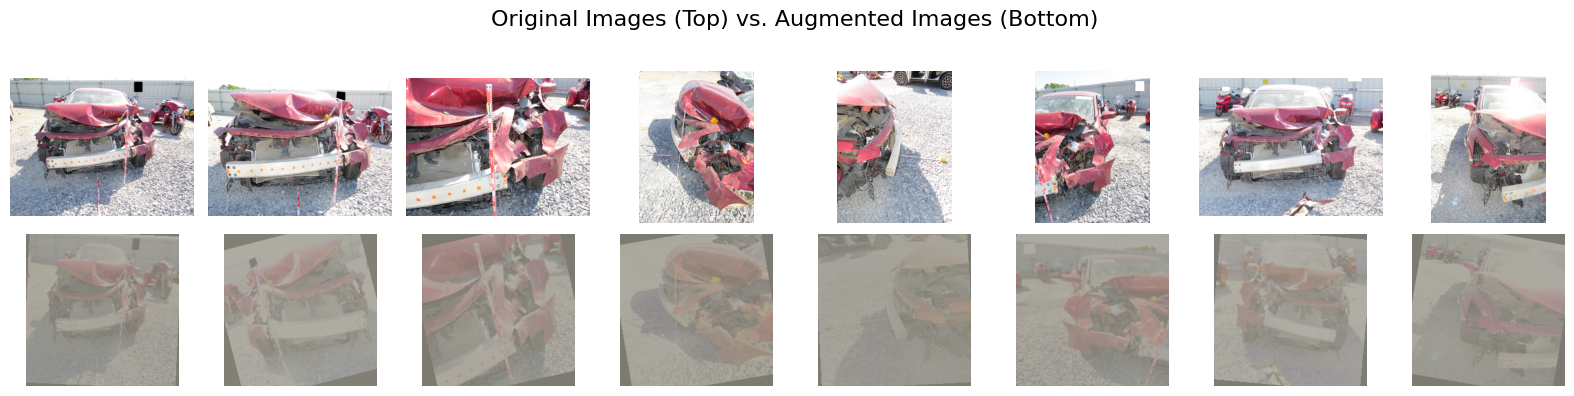

In [48]:
import matplotlib.pyplot as plt
import numpy as np

classes = raw_image_dataset.classes

def unnormalize(img_tensor):
    # Convert normalized tensor back to image for display
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def show_augmented_vs_original(transform, dataset, num_images=8):
    # Get original images (PIL) from dataset
    original_images = [dataset[i][0] for i in range(num_images)]

    # Apply augmentations
    augmented_images = [transform(img) for img in original_images]

    fig, axs = plt.subplots(2, num_images, figsize=(16, 4))
    fig.suptitle('Original Images (Top) vs. Augmented Images (Bottom)', fontsize=16)

    for i in range(num_images):
        # Display original images
        axs[0, i].imshow(original_images[i])
        axs[0, i].axis('off')
        if i == 0:
            axs[0, i].set_ylabel('Original', fontsize=12)

        # Display augmented images (unnormalized tensor)
        img = unnormalize(augmented_images[i])
        axs[1, i].imshow(img)
        axs[1, i].axis('off')
        if i == 0:
            axs[1, i].set_ylabel('Augmented', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# To use this function, pass your transform pipeline and the raw dataset without transforms:
show_augmented_vs_original(transform=TRANSFORM_IMG, dataset=raw_image_dataset)

In [ ]:
# Asegurarse de que el directorio de salida exista
os.makedirs(IMAGES_AUGMENTED_DIR, exist_ok=True)

imagenes_generadas = 0
print(f"Iniciando el aumento de datos. Meta: {TARGET_IMAGES} imágenes...")

# Usamos tqdm para ver una barra de progreso
for i in tqdm(range(TARGET_IMAGES)):
    # 1. Seleccionar una imagen aleatoria del dataset original (crudo)
    idx_aleatorio = random.randint(0, len(raw_image_dataset) - 1)
    img_pil, label = raw_image_dataset[idx_aleatorio]
    
    # 2. Aplicar el pipeline de transformaciones (esto devuelve un Tensor)
    img_tensor_aumentada = TRANSFORM_IMG(img_pil)
    
    # 3. Construir la ruta de guardado
    # Puedes incluir el label en el nombre si necesitas mantener las clases
    nombre_archivo = f"aug_{i:04d}_class_{label}.png"
    ruta_guardado = os.path.join(IMAGES_AUGMENTED_DIR, nombre_archivo)
    
    # 4. Guardar el tensor como imagen en el disco
    save_image(img_tensor_aumentada, ruta_guardado)

print(f"¡Listo! Las {TARGET_IMAGES} imágenes aumentadas se han guardado en: {IMAGES_AUGMENTED_DIR}")

Iniciando el aumento de datos. Meta: 4000 imágenes...


100%|██████████| 4000/4000 [02:42<00:00, 24.57it/s]

¡Listo! Las 4000 imágenes aumentadas se han guardado en: ./dataset_aumentado\imagesAugmented
